# 06 - Synthetic Minority-Balanced Training

Combine the selected real crop dataset `plate_crops_LLNNLLL_2` with a targeted subset of synthetic UK plate images.

Synthetic images are added only when their label contains a per-position character that is under-represented in the real dataset. The combined metadata is shuffled and then group-split by full plate label, so repeated images of the same plate cannot leak across train/validation/test.

Training target: clean `36x124` `PlateCNN`, 5 epochs.


## 1. Setup and Configuration

In [1]:
from __future__ import annotations

import math
import os
import random
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader


def find_anpr_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd,
        cwd.parent,
        cwd.parent.parent,
        cwd / "uk_plate_recognition",
        cwd.parent / "uk_plate_recognition",
    ]

    for candidate in candidates:
        if (candidate / "src" / "anpr").exists() and (candidate / "data").exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not find uk_plate_recognition project root. "
        "Run this notebook from the repository root, uk_plate_recognition/, or uk_plate_recognition/notebooks/."
    )


PROJECT_ROOT = find_anpr_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.environ.setdefault("NO_ALBUMENTATIONS_UPDATE", "1")

from anpr.data.dataset import PlateDataset
from anpr.data.encoders import POSITION_CHARSETS
from anpr.data.label_parser import parse_label_from_filename
from anpr.data.metadata import IMAGE_EXTENSIONS, make_relative_path
from anpr.data.split import assign_splits
from anpr.data.transforms import get_eval_transforms
from anpr.evaluation.metrics import format_plate_metrics
from anpr.inference.decode import decode_model_outputs
from anpr.models.plate_cnn import PlateCNN, count_trainable_parameters
from anpr.training.losses import PlateMultiHeadLoss
from anpr.training.train_loop import evaluate_one_epoch, train_one_epoch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

REAL_DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "plate_crops_LLNNLLL_2"
SYNTHETIC_DATASET_DIR = PROJECT_ROOT / "data" / "raw" / "UKLicencePlateDataset"

COMBINED_METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates_custom_synthetic_minority_balanced.csv"
SYNTHETIC_SELECTION_CSV = PROJECT_ROOT / "data" / "metadata" / "plates_synthetic_minority_selected.csv"
INVALID_METADATA_CSV = PROJECT_ROOT / "data" / "metadata" / "plates_synthetic_minority_invalid.csv"

CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints" / "synthetic_minority_36x124"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "synthetic_minority_training"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_NAME = "custom_synth_minority_clean_36x124_5ep"
IMAGE_HEIGHT = 36
IMAGE_WIDTH = 124
BATCH_SIZE = 64
NUM_EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.1
POOLED_WIDTH = 10
PLATE_LENGTH = 7
NUM_WORKERS = 0

# Median balancing is conservative: it lifts weak classes without making synthetic data dominate.
TARGET_QUANTILE = 0.50
INCLUDE_ZERO_COUNT_CHARS = False
MAX_SYNTHETIC_TO_REAL_RATIO = 1.0

BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / f"{EXPERIMENT_NAME}_best.pt"
LAST_CHECKPOINT_PATH = CHECKPOINT_DIR / f"{EXPERIMENT_NAME}_last.pt"

print("Project root:", PROJECT_ROOT)
print("Real dataset:", REAL_DATASET_DIR)
print("Synthetic dataset:", SYNTHETIC_DATASET_DIR)
print("Combined metadata:", COMBINED_METADATA_CSV)
print("Device:", DEVICE)


Project root: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition
Real dataset: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\plate_crops_LLNNLLL_2
Synthetic dataset: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\raw\UKLicencePlateDataset
Combined metadata: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\metadata\plates_custom_synthetic_minority_balanced.csv
Device: cpu


## 2. Build Combined Dataset

In [10]:
def find_image_files(image_dir: Path) -> list[Path]:
    if not image_dir.exists():
        raise FileNotFoundError(f"Image directory does not exist: {image_dir}")

    return sorted(
        path
        for path in image_dir.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS and not str(path.parent).endswith("whiteplate_augmented") and not str(path.parent).endswith("yellowplate_augmented")
    )


def make_metadata_from_images(
    image_dir: Path,
    source_name: str,
    allow_embedded_plate: bool,
    source_by_parent: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    valid_rows: list[dict[str, Any]] = []
    invalid_rows: list[dict[str, Any]] = []

    for image_path in find_image_files(image_dir):
        relative_path = make_relative_path(image_path, PROJECT_ROOT)
        source = f"{source_name}_{image_path.parent.name}" if source_by_parent else source_name

        try:
            label = parse_label_from_filename(
                image_path,
                allow_embedded_plate=allow_embedded_plate,
            )
        except ValueError as exc:
            invalid_rows.append(
                {
                    "image_path": relative_path,
                    "source": source,
                    "reason": str(exc),
                }
            )
            continue

        valid_rows.append(
            {
                "image_id": f"{source}_{image_path.stem}",
                "image_path": relative_path,
                "label": label,
                "label_length": len(label),
                "source": source,
            }
        )

    return pd.DataFrame(valid_rows), pd.DataFrame(invalid_rows)


def add_label_char_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for position in range(PLATE_LENGTH):
        df[f"char_{position}"] = df["label"].str[position]
    return df


real_df, real_invalid_df = make_metadata_from_images(
    image_dir=REAL_DATASET_DIR,
    source_name="plate_crops_LLNNLLL_2",
    allow_embedded_plate=True,
)
synthetic_df, synthetic_invalid_df = make_metadata_from_images(
    image_dir=SYNTHETIC_DATASET_DIR,
    source_name="synthetic_uk_plate",
    allow_embedded_plate=False,
    source_by_parent=True,
)

invalid_df = pd.concat([real_invalid_df, synthetic_invalid_df], ignore_index=True)
if not invalid_df.empty:
    invalid_df.to_csv(INVALID_METADATA_CSV, index=False)

real_df = add_label_char_columns(real_df)
synthetic_df = add_label_char_columns(synthetic_df)
real_df["source_group"] = "real"
synthetic_df["source_group"] = "synthetic"

print("Real rows:", len(real_df), "unique labels:", real_df["label"].nunique())
print("Synthetic candidate rows:", len(synthetic_df), "unique labels:", synthetic_df["label"].nunique())
print("Invalid rows:", len(invalid_df))
display(real_df.head())
display(synthetic_df.head())


Real rows: 12221 unique labels: 11156
Synthetic candidate rows: 24000 unique labels: 24000
Invalid rows: 0


,image_id,image_path,label,label_length,source,char_0,char_1,char_2,char_3,char_4,char_5,char_6,source_group
0,plate_crops_LLNNLLL_2_AC08UHJ,data/raw/plate_crops_LLNNLLL_2/AC08UHJ.jpg,AC08UHJ,7,plate_crops_LLNNLLL_2,A,C,0,8,U,H,J,real
1,plate_crops_LLNNLLL_2_AC08UHJ_002,data/raw/plate_crops_LLNNLLL_2/AC08UHJ_002.jpg,AC08UHJ,7,plate_crops_LLNNLLL_2,A,C,0,8,U,H,J,real
2,plate_crops_LLNNLLL_2_AC21AJW,data/raw/plate_crops_LLNNLLL_2/AC21AJW.jpg,AC21AJW,7,plate_crops_LLNNLLL_2,A,C,2,1,A,J,W,real
3,plate_crops_LLNNLLL_2_AD08CAO,data/raw/plate_crops_LLNNLLL_2/AD08CAO.jpg,AD08CAO,7,plate_crops_LLNNLLL_2,A,D,0,8,C,A,O,real
4,plate_crops_LLNNLLL_2_AD08CAO_002,data/raw/plate_crops_LLNNLLL_2/AD08CAO_002.jpg,AD08CAO,7,plate_crops_LLNNLLL_2,A,D,0,8,C,A,O,real


,image_id,image_path,label,label_length,source,char_0,char_1,char_2,char_3,char_4,char_5,char_6,source_group
0,synthetic_uk_plate_whiteplate_normal_AA03BOJ,data/raw/UKLicencePlateDataset/whiteplate_norm...,AA03BOJ,7,synthetic_uk_plate_whiteplate_normal,A,A,0,3,B,O,J,synthetic
1,synthetic_uk_plate_whiteplate_normal_AA06OHE,data/raw/UKLicencePlateDataset/whiteplate_norm...,AA06OHE,7,synthetic_uk_plate_whiteplate_normal,A,A,0,6,O,H,E,synthetic
2,synthetic_uk_plate_whiteplate_normal_AA15VJJ,data/raw/UKLicencePlateDataset/whiteplate_norm...,AA15VJJ,7,synthetic_uk_plate_whiteplate_normal,A,A,1,5,V,J,J,synthetic
3,synthetic_uk_plate_whiteplate_normal_AA19HSV,data/raw/UKLicencePlateDataset/whiteplate_norm...,AA19HSV,7,synthetic_uk_plate_whiteplate_normal,A,A,1,9,H,S,V,synthetic
4,synthetic_uk_plate_whiteplate_normal_AA22JTE,data/raw/UKLicencePlateDataset/whiteplate_norm...,AA22JTE,7,synthetic_uk_plate_whiteplate_normal,A,A,2,2,J,T,E,synthetic


## 3. Select Minority Synthetic Rows

In [11]:
def build_minority_deficit_table(real_metadata: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    for position, charset in enumerate(POSITION_CHARSETS):
        counts = real_metadata[f"char_{position}"].value_counts()
        observed_counts = counts[counts > 0]
        target_count = int(math.ceil(observed_counts.quantile(TARGET_QUANTILE)))
        chars = list(charset) if INCLUDE_ZERO_COUNT_CHARS else sorted(counts.index.tolist())

        for char in chars:
            real_count = int(counts.get(char, 0))
            deficit = max(0, target_count - real_count)
            rows.append(
                {
                    "position": position,
                    "char": char,
                    "real_count": real_count,
                    "target_count": target_count,
                    "deficit": deficit,
                    "is_minority": deficit > 0,
                }
            )

    return pd.DataFrame(rows)


def select_synthetic_for_deficits(
    synthetic_metadata: pd.DataFrame,
    deficit_table: pd.DataFrame,
    max_rows: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    remaining = {
        (int(row.position), str(row.char)): int(row.deficit)
        for row in deficit_table.itertuples(index=False)
        if int(row.deficit) > 0
    }
    selected_indices: list[int] = []
    shuffled = synthetic_metadata.sample(frac=1, random_state=RANDOM_STATE).reset_index()

    for _, row in shuffled.iterrows():
        hits = []
        for position in range(PLATE_LENGTH):
            key = (position, row[f"char_{position}"])
            if remaining.get(key, 0) > 0:
                hits.append(key)

        if not hits:
            continue

        selected_indices.append(int(row["index"]))
        for key in set(hits):
            remaining[key] = max(0, remaining[key] - 1)

        if len(selected_indices) >= max_rows or all(value <= 0 for value in remaining.values()):
            break

    selected = synthetic_metadata.loc[selected_indices].copy()
    remaining_rows = []
    for row in deficit_table.itertuples(index=False):
        key = (int(row.position), str(row.char))
        remaining_rows.append(
            {
                "position": int(row.position),
                "char": str(row.char),
                "real_count": int(row.real_count),
                "target_count": int(row.target_count),
                "initial_deficit": int(row.deficit),
                "remaining_deficit": int(remaining.get(key, 0)),
            }
        )

    return selected, pd.DataFrame(remaining_rows)


minority_deficit_df = build_minority_deficit_table(real_df)
max_synthetic_rows = int(len(real_df) * MAX_SYNTHETIC_TO_REAL_RATIO)
selected_synthetic_df, remaining_deficit_df = select_synthetic_for_deficits(
    synthetic_metadata=synthetic_df,
    deficit_table=minority_deficit_df,
    max_rows=max_synthetic_rows,
)
selected_synthetic_df.to_csv(SYNTHETIC_SELECTION_CSV, index=False)

print("Target quantile:", TARGET_QUANTILE)
print("Include zero-count chars:", INCLUDE_ZERO_COUNT_CHARS)
print("Max synthetic rows:", max_synthetic_rows)
print("Selected synthetic rows:", len(selected_synthetic_df))
print("Saved selected synthetic metadata:", SYNTHETIC_SELECTION_CSV)

display(
    minority_deficit_df[minority_deficit_df["is_minority"]]
    .sort_values(["deficit", "position", "char"], ascending=[False, True, True])
    .head(40)
)
display(
    remaining_deficit_df[remaining_deficit_df["initial_deficit"] > 0]
    .sort_values(["remaining_deficit", "initial_deficit"], ascending=False)
    .head(40)
)


Target quantile: 0.5
Include zero-count chars: False
Max synthetic rows: 12221
Selected synthetic rows: 6022
Saved selected synthetic metadata: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\metadata\plates_synthetic_minority_selected.csv


,position,char,real_count,target_count,deficit,is_minority
43,2,0,297,1381,1084,True
46,2,5,301,1381,1080,True
55,3,6,289,840,551,True
8,0,J,1,534,533,True
56,3,7,393,840,447,True
13,0,O,240,534,294,True
21,1,B,226,510,284,True
75,4,S,234,512,278,True
57,3,8,570,840,270,True
83,5,A,222,472,250,True


,position,char,real_count,target_count,initial_deficit,remaining_deficit
43,2,0,297,1381,1084,0
46,2,5,301,1381,1080,0
55,3,6,289,840,551,0
8,0,J,1,534,533,0
56,3,7,393,840,447,0
13,0,O,240,534,294,0
21,1,B,226,510,284,0
75,4,S,234,512,278,0
57,3,8,570,840,270,0
83,5,A,222,472,250,0


## 4. Split, Shuffle, and Test for Leakage

In [12]:
combined_unsplit_df = pd.concat([real_df, selected_synthetic_df], ignore_index=True)
combined_unsplit_df = combined_unsplit_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

combined_df = assign_splits(
    combined_unsplit_df,
    train_size=0.8,
    val_size=0.1,
    test_size=0.1,
    group_col="label",
    random_state=RANDOM_STATE,
)
combined_df = combined_df.sample(frac=1, random_state=RANDOM_STATE + 1).reset_index(drop=True)
combined_df.to_csv(COMBINED_METADATA_CSV, index=False)

label_split_counts = combined_df.groupby("label")["split"].nunique()
leaked_labels = label_split_counts[label_split_counts > 1]
assert leaked_labels.empty, f"Found labels in multiple splits: {leaked_labels.head().to_dict()}"

duplicate_paths = combined_df[combined_df["image_path"].duplicated(keep=False)]
assert duplicate_paths.empty, f"Found duplicate image paths: {duplicate_paths.head()}"

if combined_df["source_group"].nunique() > 1:
    assert combined_df["source_group"].head(100).nunique() > 1, "Combined metadata is not source-mixed at the top."

same_label_multiple_images = (
    combined_df.groupby("label")
    .agg(images=("image_path", "size"), splits=("split", "nunique"), sources=("source_group", "nunique"))
    .query("images > 1")
    .sort_values("images", ascending=False)
)
assert (same_label_multiple_images["splits"] == 1).all()

test_duplicate_labels = (
    combined_df[combined_df["split"] == "test"]
    .groupby("label")
    .size()
    .loc[lambda values: values > 1]
    .sort_values(ascending=False)
)

print("Saved combined metadata:", COMBINED_METADATA_CSV)
print("Rows:", len(combined_df), "Unique labels:", combined_df["label"].nunique())
print("Leakage test passed: every plate label appears in exactly one split.")
print("Duplicate image path test passed.")
print("Shuffle smoke test passed.")
print("Labels with multiple images:", len(same_label_multiple_images))
print("Labels with multiple images inside test:", len(test_duplicate_labels))
display(pd.crosstab(combined_df["split"], combined_df["source_group"], margins=True))
display(pd.crosstab(combined_df["source"], combined_df["split"], margins=True))
display(same_label_multiple_images.head(20))
display(test_duplicate_labels.head(20).to_frame("test_images_for_label"))


Saved combined metadata: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\data\metadata\plates_custom_synthetic_minority_balanced.csv
Rows: 18243 Unique labels: 17178
Leakage test passed: every plate label appears in exactly one split.
Duplicate image path test passed.
Shuffle smoke test passed.
Labels with multiple images: 724
Labels with multiple images inside test: 78


source_group,real,synthetic,All
split,,,
test,1230,602,1832
train,9719,4835,14554
val,1272,585,1857
All,12221,6022,18243


split,test,train,val,All
source,,,,
plate_crops_LLNNLLL_2,1230,9719,1272,12221
synthetic_uk_plate_whiteplate_normal,303,2402,286,2991
synthetic_uk_plate_yellowplate_normal,299,2433,299,3031
All,1832,14554,1857,18243


,images,splits,sources
label,,,
VU68LHN,6,1,1
SM08CMU,4,1,1
CY70FMZ,4,1,1
DS68FJV,4,1,1
VX18ORK,4,1,1
EA74THK,4,1,1
FT23VRC,4,1,1
MD23RWW,4,1,1
HV14MVR,4,1,1


,test_images_for_label
label,
LR67YJU,4
KN62WFD,4
AO14LHF,3
AO14BHD,3
AF15YLR,3
AK58YXZ,3
DK55OVL,3
BV13WEU,3
CV16FUB,3


## 5. Data Loaders

In [13]:
eval_transform = get_eval_transforms(image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH)


def make_dataset(split: str, metadata: str | Path | pd.DataFrame = COMBINED_METADATA_CSV) -> PlateDataset:
    return PlateDataset(
        metadata=metadata,
        project_root=PROJECT_ROOT,
        split=split if not isinstance(metadata, pd.DataFrame) else None,
        transform=eval_transform,
        grayscale=True,
    )


def make_loader(dataset: PlateDataset, shuffle: bool) -> DataLoader:
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )


train_ds = make_dataset("train")
val_ds = make_dataset("val")
test_ds = make_dataset("test")

train_loader = make_loader(train_ds, shuffle=True)
val_loader = make_loader(val_ds, shuffle=False)
test_loader = make_loader(test_ds, shuffle=False)

print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))
sample = train_ds[0]
print("Sample image shape:", tuple(sample["image"].shape))
print("Sample target shape:", tuple(sample["target"].shape))
print("Sample label:", sample["label"])

batch = next(iter(train_loader))
print("Batch image shape:", tuple(batch["image"].shape))
print("Batch target shape:", tuple(batch["target"].shape))


Dataset sizes: 14554 1857 1832
Sample image shape: (1, 36, 124)
Sample target shape: (7,)
Sample label: WH07LUP
Batch image shape: (64, 1, 36, 124)
Batch target shape: (64, 7)


## 6. Training Helpers

In [14]:
def build_model() -> PlateCNN:
    return PlateCNN(in_channels=1, dropout=DROPOUT, pooled_width=POOLED_WIDTH).to(DEVICE)


def get_current_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def history_row(epoch: int, train_result, val_result, lr: float) -> dict[str, Any]:
    metrics = val_result.metrics
    row = {
        "epoch": epoch,
        "lr": lr,
        "train_loss": train_result.loss,
        "val_loss": val_result.loss,
        "val_full_plate_accuracy": metrics.full_plate_accuracy,
        "val_regex_valid_rate": metrics.regex_valid_rate,
        "val_average_confidence": metrics.average_confidence,
    }
    for position, accuracy in enumerate(metrics.per_position_accuracy):
        row[f"val_position_{position}_acc"] = accuracy
    return row


def save_checkpoint(
    path: Path,
    model: PlateCNN,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau,
    epoch: int,
    best_val_accuracy: float,
    best_val_loss: float,
    history: list[dict[str, Any]],
) -> None:
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch": epoch,
            "best_val_accuracy": best_val_accuracy,
            "best_val_loss": best_val_loss,
            "history": history,
            "model_config": {
                "in_channels": 1,
                "dropout": DROPOUT,
                "pooled_width": POOLED_WIDTH,
                "image_height": IMAGE_HEIGHT,
                "image_width": IMAGE_WIDTH,
                "grayscale": True,
            },
            "experiment_config": {
                "experiment_name": EXPERIMENT_NAME,
                "metadata_csv": str(COMBINED_METADATA_CSV),
                "selected_synthetic_csv": str(SYNTHETIC_SELECTION_CSV),
                "num_epochs": NUM_EPOCHS,
                "lr": LR,
                "weight_decay": WEIGHT_DECAY,
                "batch_size": BATCH_SIZE,
                "target_quantile": TARGET_QUANTILE,
                "max_synthetic_to_real_ratio": MAX_SYNTHETIC_TO_REAL_RATIO,
                "random_state": RANDOM_STATE,
            },
        },
        path,
    )


def load_checkpoint_model(checkpoint_path: Path) -> tuple[PlateCNN, dict[str, Any]]:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    config = checkpoint["model_config"]
    model = PlateCNN(
        in_channels=config["in_channels"],
        dropout=config["dropout"],
        pooled_width=config["pooled_width"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


def evaluate_model(model: PlateCNN, loader: DataLoader, label: str):
    result = evaluate_one_epoch(model, loader, PlateMultiHeadLoss(), DEVICE, show_progress=True)
    print(f"{label} loss:", result.loss)
    print(format_plate_metrics(result.metrics))
    return result


## 7. Train 36x124 Model for 5 Epochs

=== custom_synth_minority_clean_36x124_5ep ===
Image size: (36, 124)
Epochs: 5
Trainable parameters: 772470


Training:   0%|          | 0/228 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 01 | lr=1.00e-03 -> 1.00e-03 | train_loss=1.4270 | val_loss=0.3442 | val_full_plate_acc=0.6774 | confidence=0.7929 | saved_best=True


Training:   0%|          | 0/228 [00:00<?, ?it/s]

...

Epoch 04 | lr=1.00e-03 -> 1.00e-03 | train_loss=0.0395 | val_loss=0.0649 | val_full_plate_acc=0.9235 | confidence=0.9761 | saved_best=True


Training:   0%|          | 0/228 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 05 | lr=1.00e-03 -> 1.00e-03 | train_loss=0.0261 | val_loss=0.0616 | val_full_plate_acc=0.9354 | confidence=0.9795 | saved_best=True
Saved history: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_history.csv


,epoch,lr,train_loss,val_loss,val_full_plate_accuracy,val_regex_valid_rate,val_average_confidence,val_position_0_acc,val_position_1_acc,val_position_2_acc,val_position_3_acc,val_position_4_acc,val_position_5_acc,val_position_6_acc,next_lr
0,1,0.001,1.427021,0.344221,0.677437,1.0,0.792888,0.942380,0.928379,0.964997,0.966613,0.908993,0.858912,0.939688,0.001
1,2,0.001,0.168639,0.122654,0.880452,1.0,0.931323,0.984383,0.973075,0.979537,0.981691,0.963920,0.953150,0.978998,0.001
2,3,0.001,0.068294,0.086743,0.909532,1.0,0.959484,0.989230,0.982229,0.988153,0.984383,0.973075,0.953689,0.984922,0.001
3,4,0.001,0.039464,0.064919,0.923533,1.0,0.976137,0.993538,0.980075,0.990845,0.987076,0.978460,0.962843,0.985460,0.001
4,5,0.001,0.026100,0.061586,0.935380,1.0,0.979548,0.991384,0.990845,0.989768,0.987614,0.982229,0.966074,0.984922,0.001


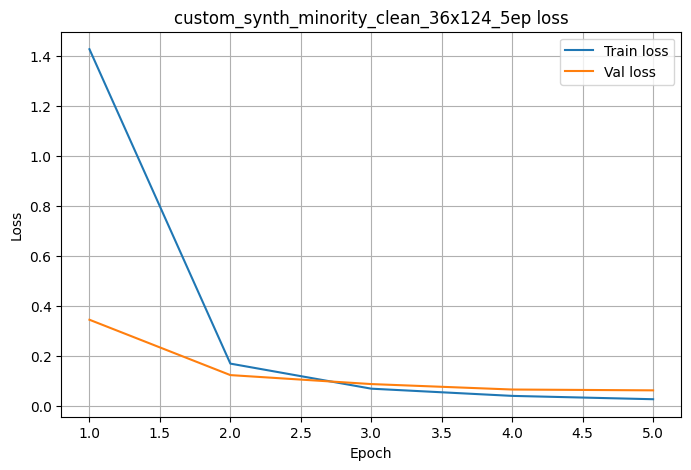

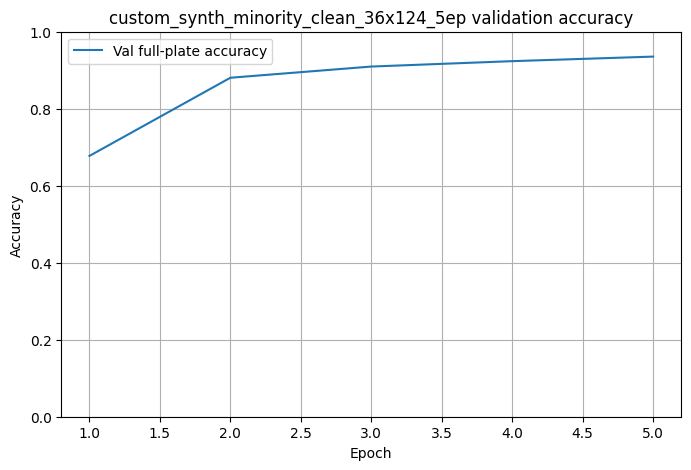

In [15]:
model = build_model()
loss_fn = PlateMultiHeadLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

best_val_accuracy = -1.0
best_val_loss = float("inf")
history: list[dict[str, Any]] = []

print(f"=== {EXPERIMENT_NAME} ===")
print("Image size:", (IMAGE_HEIGHT, IMAGE_WIDTH))
print("Epochs:", NUM_EPOCHS)
print("Trainable parameters:", count_trainable_parameters(model))

for epoch in range(1, NUM_EPOCHS + 1):
    lr_used = get_current_lr(optimizer)
    train_result = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE, show_progress=True)
    val_result = evaluate_one_epoch(model, val_loader, loss_fn, DEVICE, show_progress=True)

    row = history_row(epoch, train_result, val_result, lr_used)
    history.append(row)
    scheduler.step(row["val_full_plate_accuracy"])
    row["next_lr"] = get_current_lr(optimizer)

    is_new_best = (
        row["val_full_plate_accuracy"] > best_val_accuracy
        or (row["val_full_plate_accuracy"] == best_val_accuracy and row["val_loss"] < best_val_loss)
    )
    if is_new_best:
        best_val_accuracy = row["val_full_plate_accuracy"]
        best_val_loss = row["val_loss"]
        save_checkpoint(BEST_CHECKPOINT_PATH, model, optimizer, scheduler, epoch, best_val_accuracy, best_val_loss, history)
        best_marker = " | saved_best=True"
    else:
        best_marker = ""

    save_checkpoint(LAST_CHECKPOINT_PATH, model, optimizer, scheduler, epoch, best_val_accuracy, best_val_loss, history)
    print(
        f"Epoch {epoch:02d} | lr={lr_used:.2e} -> {row['next_lr']:.2e} | "
        f"train_loss={train_result.loss:.4f} | "
        f"val_loss={val_result.loss:.4f} | "
        f"val_full_plate_acc={row['val_full_plate_accuracy']:.4f} | "
        f"confidence={row['val_average_confidence']:.4f}"
        f"{best_marker}"
    )

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_history.csv"
history_df.to_csv(history_path, index=False)
print("Saved history:", history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{EXPERIMENT_NAME} loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_full_plate_accuracy"], label="Val full-plate accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{EXPERIMENT_NAME} validation accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()


## 8. Evaluate Test Sets

In [16]:
def loader_from_filtered_df(filtered_df: pd.DataFrame) -> DataLoader | None:
    if filtered_df.empty:
        return None
    dataset = PlateDataset(
        metadata=filtered_df.copy(),
        project_root=PROJECT_ROOT,
        split=None,
        transform=eval_transform,
        grayscale=True,
    )
    return make_loader(dataset, shuffle=False)


def export_predictions(model: PlateCNN, loader: DataLoader, filename: str) -> pd.DataFrame:
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE)
            labels = list(batch["label"])
            image_paths = list(batch["image_path"])
            predictions = decode_model_outputs(model(images))

            for image_path, true_label, prediction in zip(image_paths, labels, predictions):
                predicted_label = prediction.cleaned_prediction
                row = {
                    "image_path": image_path,
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "correct": predicted_label == true_label,
                    "confidence": prediction.overall_confidence,
                    "regex_valid": prediction.is_valid_format,
                }
                for position in range(PLATE_LENGTH):
                    row[f"true_pos_{position}"] = true_label[position]
                    row[f"pred_pos_{position}"] = predicted_label[position]
                    row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                    row[f"pos_{position}_confidence"] = prediction.position_confidences[position]
                rows.append(row)

    predictions_df = pd.DataFrame(rows)
    output_path = OUTPUT_DIR / filename
    predictions_df.to_csv(output_path, index=False)
    print("Saved predictions:", output_path)
    return predictions_df


best_model, best_checkpoint = load_checkpoint_model(BEST_CHECKPOINT_PATH)
test_metadata_df = combined_df[combined_df["split"] == "test"].copy()
real_test_metadata_df = test_metadata_df[test_metadata_df["source_group"] == "real"].copy()
synthetic_test_metadata_df = test_metadata_df[test_metadata_df["source_group"] == "synthetic"].copy()

loaders = {
    "combined_test": test_loader,
    "real_only_test": loader_from_filtered_df(real_test_metadata_df),
    "synthetic_only_test": loader_from_filtered_df(synthetic_test_metadata_df),
}

summary_rows = []
prediction_tables: dict[str, pd.DataFrame] = {}

for name, loader in loaders.items():
    if loader is None:
        print(f"Skipping {name}; no rows in this subset.")
        continue

    result = evaluate_model(best_model, loader, f"{EXPERIMENT_NAME} {name}")
    summary_rows.append(
        {
            "experiment": EXPERIMENT_NAME,
            "subset": name,
            "rows": result.metrics.num_samples,
            "loss": result.loss,
            "full_plate_accuracy": result.metrics.full_plate_accuracy,
            "regex_valid_rate": result.metrics.regex_valid_rate,
            "average_confidence": result.metrics.average_confidence,
            "best_epoch": best_checkpoint["epoch"],
            "best_val_accuracy": best_checkpoint["best_val_accuracy"],
            "checkpoint_path": str(BEST_CHECKPOINT_PATH),
        }
    )
    prediction_tables[name] = export_predictions(best_model, loader, f"{EXPERIMENT_NAME}_{name}_predictions.csv")

summary_df = pd.DataFrame(summary_rows)
summary_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_evaluation_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved evaluation summary:", summary_path)
display(summary_df)


Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]

custom_synth_minority_clean_36x124_5ep combined_test loss: 0.05401438295711076
Samples: 1832
Full-plate accuracy: 0.9312
Regex-valid rate: 1.0000
Average confidence: 0.9818
Per-position accuracy:
  Position 0: 0.9907
  Position 1: 0.9885
  Position 2: 0.9913
  Position 3: 0.9880
  Position 4: 0.9864
  Position 5: 0.9602
  Position 6: 0.9874
Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_combined_test_predictions.csv


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

custom_synth_minority_clean_36x124_5ep real_only_test loss: 0.07762947775484101
Samples: 1230
Full-plate accuracy: 0.9000
Regex-valid rate: 1.0000
Average confidence: 0.9751
Per-position accuracy:
  Position 0: 0.9862
  Position 1: 0.9829
  Position 2: 0.9870
  Position 3: 0.9821
  Position 4: 0.9813
  Position 5: 0.9423
  Position 6: 0.9821
Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_real_only_test_predictions.csv


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

custom_synth_minority_clean_36x124_5ep synthetic_only_test loss: 0.005764268154581619
Samples: 602
Full-plate accuracy: 0.9950
Regex-valid rate: 1.0000
Average confidence: 0.9954
Per-position accuracy:
  Position 0: 1.0000
  Position 1: 1.0000
  Position 2: 1.0000
  Position 3: 1.0000
  Position 4: 0.9967
  Position 5: 0.9967
  Position 6: 0.9983
Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_synthetic_only_test_predictions.csv
Saved evaluation summary: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_evaluation_summary.csv


,experiment,subset,rows,loss,full_plate_accuracy,regex_valid_rate,average_confidence,best_epoch,best_val_accuracy,checkpoint_path
0,custom_synth_minority_clean_36x124_5ep,combined_test,1832,0.054014,0.931223,1.0,0.981774,5,0.93538,C:\Users\kosko\OneDrive\Python\machine_learnin...
1,custom_synth_minority_clean_36x124_5ep,real_only_test,1230,0.077629,0.900000,1.0,0.975084,5,0.93538,C:\Users\kosko\OneDrive\Python\machine_learnin...
2,custom_synth_minority_clean_36x124_5ep,synthetic_only_test,602,0.005764,0.995017,1.0,0.995443,5,0.93538,C:\Users\kosko\OneDrive\Python\machine_learnin...


## 9. Error Analysis

In [17]:
def position_error_summary(predictions_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "position": position,
            "accuracy": predictions_df[f"pos_{position}_correct"].mean(),
            "errors": (~predictions_df[f"pos_{position}_correct"]).sum(),
        }
        for position in range(PLATE_LENGTH)
    )


def character_errors(predictions_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in predictions_df[~predictions_df["correct"]].iterrows():
        for position in range(PLATE_LENGTH):
            true_char = row["true_label"][position]
            pred_char = row["predicted_label"][position]
            if true_char != pred_char:
                rows.append(
                    {
                        "image_path": row["image_path"],
                        "true_label": row["true_label"],
                        "predicted_label": row["predicted_label"],
                        "position": position,
                        "true_char": true_char,
                        "pred_char": pred_char,
                        "plate_confidence": row["confidence"],
                        "position_confidence": row[f"pos_{position}_confidence"],
                    }
                )
    return pd.DataFrame(rows)


for subset_name, predictions_df in prediction_tables.items():
    errors_df = predictions_df[~predictions_df["correct"]].copy()
    print("Subset:", subset_name)
    print("Rows:", len(predictions_df))
    print("Errors:", len(errors_df))
    print("Accuracy:", predictions_df["correct"].mean())

    display(position_error_summary(predictions_df))
    display(
        errors_df.sort_values("confidence", ascending=False)[
            ["image_path", "true_label", "predicted_label", "confidence", "regex_valid"]
        ].head(30)
    )

    char_errors_df = character_errors(predictions_df)
    char_errors_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_{subset_name}_character_errors.csv"
    char_errors_df.to_csv(char_errors_path, index=False)
    print("Saved character errors:", char_errors_path)
    if not char_errors_df.empty:
        display(
            char_errors_df.groupby(["position", "true_char", "pred_char"])
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
            .head(30)
        )


Subset: combined_test
Rows: 1832
Errors: 126
Accuracy: 0.9312227074235808


,position,accuracy,errors
0,0,0.990721,17
1,1,0.988537,21
2,2,0.991266,16
3,3,0.987991,22
4,4,0.986354,25
5,5,0.960153,73
6,6,0.987445,23


,image_path,true_label,predicted_label,confidence,regex_valid
1474,C:\Users\kosko\OneDrive\Python\machine_learnin...,EK72ZOT,EK72ZDT,0.988835,True
1694,C:\Users\kosko\OneDrive\Python\machine_learnin...,BG11FZX,BG11FXX,0.986505,True
819,C:\Users\kosko\OneDrive\Python\machine_learnin...,SJ19VME,SJ19MME,0.980221,True
57,C:\Users\kosko\OneDrive\Python\machine_learnin...,YD75ELO,YD75EEO,0.980182,True
273,C:\Users\kosko\OneDrive\Python\machine_learnin...,BT61PFO,BT61FFO,0.979547,True
1287,C:\Users\kosko\OneDrive\Python\machine_learnin...,BG11FZX,BG11FXX,0.977584,True
1650,C:\Users\kosko\OneDrive\Python\machine_learnin...,KR26JPV,KR26JJV,0.976662,True
877,C:\Users\kosko\OneDrive\Python\machine_learnin...,BG11FZX,BG11FXX,0.973485,True
1308,C:\Users\kosko\OneDrive\Python\machine_learnin...,MT12DZP,MT12DPP,0.972036,True
316,C:\Users\kosko\OneDrive\Python\machine_learnin...,AK58YXZ,AK68YXZ,0.969988,True


Saved character errors: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_combined_test_character_errors.csv


,position,true_char,pred_char,count
39,2,5,6,5
129,5,Z,X,4
79,5,C,G,3
33,2,0,6,3
99,5,O,D,3
54,3,7,0,3
92,5,K,X,3
121,5,Y,K,3
36,2,1,6,2
68,4,N,Y,2


...

Subset: synthetic_only_test
Rows: 602
Errors: 3
Accuracy: 0.9950166112956811


,position,accuracy,errors
0,0,1.000000,0
1,1,1.000000,0
2,2,1.000000,0
3,3,1.000000,0
4,4,0.996678,2
5,5,0.996678,2
6,6,0.998339,1


,image_path,true_label,predicted_label,confidence,regex_valid
127,C:\Users\kosko\OneDrive\Python\machine_learnin...,OX19IKF,OX19KKF,0.931097,True
308,C:\Users\kosko\OneDrive\Python\machine_learnin...,JK11IIQ,JK11IQL,0.849786,True
230,C:\Users\kosko\OneDrive\Python\machine_learnin...,IB81LOD,IB81ADD,0.844524,True


Saved character errors: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_synthetic_only_test_character_errors.csv


,position,true_char,pred_char,count
0,4,I,K,1
1,4,L,A,1
2,5,I,Q,1
3,5,O,D,1
4,6,Q,L,1


Training:   0%|          | 0/228 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 01 | lr=1.00e-03 -> 1.00e-03 | train_loss=0.0171 | val_loss=0.0510 | val_full_plate_acc=0.9402 | confidence=0.9852 | saved_best=True


Training:   0%|          | 0/228 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

...

Epoch 04 | lr=1.00e-03 -> 1.00e-03 | train_loss=0.0100 | val_loss=0.0491 | val_full_plate_acc=0.9467 | confidence=0.9881


Training:   0%|          | 0/228 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch 05 | lr=1.00e-03 -> 5.00e-04 | train_loss=0.0083 | val_loss=0.0505 | val_full_plate_acc=0.9461 | confidence=0.9884
Saved history: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_history.csv


,epoch,lr,train_loss,val_loss,val_full_plate_accuracy,val_regex_valid_rate,val_average_confidence,val_position_0_acc,val_position_1_acc,val_position_2_acc,val_position_3_acc,val_position_4_acc,val_position_5_acc,val_position_6_acc,next_lr
0,1,0.001,0.017124,0.051014,0.940226,1.0,0.985235,0.992461,0.990845,0.989768,0.988691,0.983845,0.976306,0.989768,0.0010
1,2,0.001,0.012533,0.048464,0.947765,1.0,0.985892,0.994076,0.990307,0.989230,0.988691,0.986537,0.977921,0.989230,0.0010
2,3,0.001,0.010820,0.058169,0.928918,1.0,0.985966,0.989768,0.989230,0.991922,0.984922,0.983306,0.969305,0.980614,0.0010
3,4,0.001,0.009987,0.049109,0.946688,1.0,0.988135,0.994076,0.989768,0.993538,0.987076,0.984383,0.978998,0.988153,0.0010
4,5,0.001,0.008254,0.050522,0.946150,1.0,0.988398,0.994615,0.991384,0.991384,0.989230,0.985460,0.974152,0.990307,0.0005


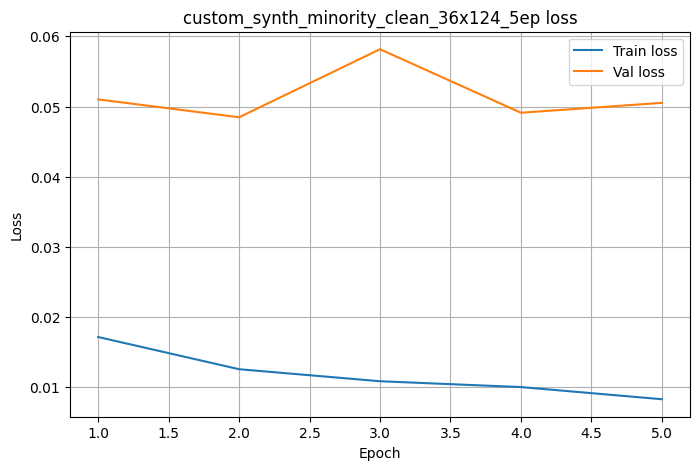

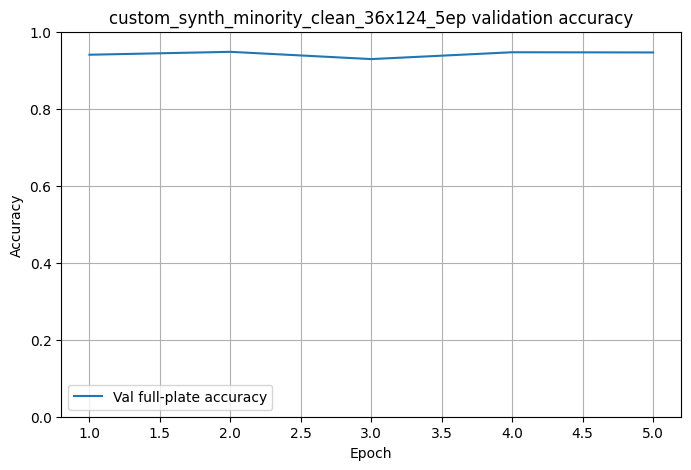

In [18]:
best_val_accuracy = -1.0
best_val_loss = float("inf")
history: list[dict[str, Any]] = []

for epoch in range(1, NUM_EPOCHS + 1):
    lr_used = get_current_lr(optimizer)
    train_result = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE, show_progress=True)
    val_result = evaluate_one_epoch(model, val_loader, loss_fn, DEVICE, show_progress=True)

    row = history_row(epoch, train_result, val_result, lr_used)
    history.append(row)
    scheduler.step(row["val_full_plate_accuracy"])
    row["next_lr"] = get_current_lr(optimizer)

    is_new_best = (
        row["val_full_plate_accuracy"] > best_val_accuracy
        or (row["val_full_plate_accuracy"] == best_val_accuracy and row["val_loss"] < best_val_loss)
    )
    if is_new_best:
        best_val_accuracy = row["val_full_plate_accuracy"]
        best_val_loss = row["val_loss"]
        save_checkpoint(BEST_CHECKPOINT_PATH, model, optimizer, scheduler, epoch, best_val_accuracy, best_val_loss, history)
        best_marker = " | saved_best=True"
    else:
        best_marker = ""

    save_checkpoint(LAST_CHECKPOINT_PATH, model, optimizer, scheduler, epoch, best_val_accuracy, best_val_loss, history)
    print(
        f"Epoch {epoch:02d} | lr={lr_used:.2e} -> {row['next_lr']:.2e} | "
        f"train_loss={train_result.loss:.4f} | "
        f"val_loss={val_result.loss:.4f} | "
        f"val_full_plate_acc={row['val_full_plate_accuracy']:.4f} | "
        f"confidence={row['val_average_confidence']:.4f}"
        f"{best_marker}"
    )

history_df = pd.DataFrame(history)
history_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_history.csv"
history_df.to_csv(history_path, index=False)
print("Saved history:", history_path)
display(history_df)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{EXPERIMENT_NAME} loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_full_plate_accuracy"], label="Val full-plate accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{EXPERIMENT_NAME} validation accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def loader_from_filtered_df(filtered_df: pd.DataFrame) -> DataLoader | None:
    if filtered_df.empty:
        return None
    dataset = PlateDataset(
        metadata=filtered_df.copy(),
        project_root=PROJECT_ROOT,
        split=None,
        transform=eval_transform,
        grayscale=True,
    )
    return make_loader(dataset, shuffle=False)


def export_predictions(model: PlateCNN, loader: DataLoader, filename: str) -> pd.DataFrame:
    rows = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(DEVICE)
            labels = list(batch["label"])
            image_paths = list(batch["image_path"])
            predictions = decode_model_outputs(model(images))

            for image_path, true_label, prediction in zip(image_paths, labels, predictions):
                predicted_label = prediction.cleaned_prediction
                row = {
                    "image_path": image_path,
                    "true_label": true_label,
                    "predicted_label": predicted_label,
                    "correct": predicted_label == true_label,
                    "confidence": prediction.overall_confidence,
                    "regex_valid": prediction.is_valid_format,
                }
                for position in range(PLATE_LENGTH):
                    row[f"true_pos_{position}"] = true_label[position]
                    row[f"pred_pos_{position}"] = predicted_label[position]
                    row[f"pos_{position}_correct"] = true_label[position] == predicted_label[position]
                    row[f"pos_{position}_confidence"] = prediction.position_confidences[position]
                rows.append(row)

    predictions_df = pd.DataFrame(rows)
    output_path = OUTPUT_DIR / filename
    predictions_df.to_csv(output_path, index=False)
    print("Saved predictions:", output_path)
    return predictions_df


best_model, best_checkpoint = load_checkpoint_model(BEST_CHECKPOINT_PATH)
test_metadata_df = combined_df[combined_df["split"] == "test"].copy()
real_test_metadata_df = test_metadata_df[test_metadata_df["source_group"] == "real"].copy()
synthetic_test_metadata_df = test_metadata_df[test_metadata_df["source_group"] == "synthetic"].copy()

loaders = {
    "combined_test": test_loader,
    "real_only_test": loader_from_filtered_df(real_test_metadata_df),
    "synthetic_only_test": loader_from_filtered_df(synthetic_test_metadata_df),
}

summary_rows = []
prediction_tables: dict[str, pd.DataFrame] = {}

for name, loader in loaders.items():
    if loader is None:
        print(f"Skipping {name}; no rows in this subset.")
        continue

    result = evaluate_model(best_model, loader, f"{EXPERIMENT_NAME} {name}")
    summary_rows.append(
        {
            "experiment": EXPERIMENT_NAME,
            "subset": name,
            "rows": result.metrics.num_samples,
            "loss": result.loss,
            "full_plate_accuracy": result.metrics.full_plate_accuracy,
            "regex_valid_rate": result.metrics.regex_valid_rate,
            "average_confidence": result.metrics.average_confidence,
            "best_epoch": best_checkpoint["epoch"],
            "best_val_accuracy": best_checkpoint["best_val_accuracy"],
            "checkpoint_path": str(BEST_CHECKPOINT_PATH),
        }
    )
    prediction_tables[name] = export_predictions(best_model, loader, f"{EXPERIMENT_NAME}_{name}_predictions.csv")

summary_df = pd.DataFrame(summary_rows)
summary_path = OUTPUT_DIR / f"{EXPERIMENT_NAME}_evaluation_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved evaluation summary:", summary_path)
display(summary_df)


Evaluating:   0%|          | 0/29 [00:00<?, ?it/s]

custom_synth_minority_clean_36x124_5ep combined_test loss: 0.0466573725100688
Samples: 1832
Full-plate accuracy: 0.9443
Regex-valid rate: 1.0000
Average confidence: 0.9862
Per-position accuracy:
  Position 0: 0.9956
  Position 1: 0.9924
  Position 2: 0.9913
  Position 3: 0.9880
  Position 4: 0.9836
  Position 5: 0.9683
  Position 6: 0.9902
Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_combined_test_predictions.csv


Evaluating:   0%|          | 0/20 [00:00<?, ?it/s]

custom_synth_minority_clean_36x124_5ep real_only_test loss: 0.06707793831582962
Samples: 1230
Full-plate accuracy: 0.9203
Regex-valid rate: 1.0000
Average confidence: 0.9812
Per-position accuracy:
  Position 0: 0.9935
  Position 1: 0.9894
  Position 2: 0.9870
  Position 3: 0.9821
  Position 4: 0.9764
  Position 5: 0.9545
  Position 6: 0.9862
Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_real_only_test_predictions.csv


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

custom_synth_minority_clean_36x124_5ep synthetic_only_test loss: 0.004934292303651967
Samples: 602
Full-plate accuracy: 0.9934
Regex-valid rate: 1.0000
Average confidence: 0.9964
Per-position accuracy:
  Position 0: 1.0000
  Position 1: 0.9983
  Position 2: 1.0000
  Position 3: 1.0000
  Position 4: 0.9983
  Position 5: 0.9967
  Position 6: 0.9983
Saved predictions: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_synthetic_only_test_predictions.csv
Saved evaluation summary: C:\Users\kosko\OneDrive\Python\machine_learning\Projects\Car-Parking\uk_plate_recognition\outputs\synthetic_minority_training\custom_synth_minority_clean_36x124_5ep_evaluation_summary.csv


,experiment,subset,rows,loss,full_plate_accuracy,regex_valid_rate,average_confidence,best_epoch,best_val_accuracy,checkpoint_path
0,custom_synth_minority_clean_36x124_5ep,combined_test,1832,0.046657,0.944323,1.0,0.986220,2,0.947765,C:\Users\kosko\OneDrive\Python\machine_learnin...
1,custom_synth_minority_clean_36x124_5ep,real_only_test,1230,0.067078,0.920325,1.0,0.981220,2,0.947765,C:\Users\kosko\OneDrive\Python\machine_learnin...
2,custom_synth_minority_clean_36x124_5ep,synthetic_only_test,602,0.004934,0.993355,1.0,0.996437,2,0.947765,C:\Users\kosko\OneDrive\Python\machine_learnin...
